# Predicción de la Demanda Turística en Ushuaia
## Aprendizaje Automático — Instancia Parcial 2026
**Alumno:** Martínez, Darío  
**Dataset:** Turismo + Clima Ushuaia (2004–2025)  
**Fuentes:** IPIEC · Open-Meteo  
**Modelo:** Regresión Lineal Múltiple  
**Variables objetivo:** Viajeros totales · Pernoctaciones · Visitas al Parque Nacional

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Estilo general de los gráficos
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         11,
})

# Paleta de colores consistente
AZUL   = '#2E75B6'
VERDE  = '#70AD47'
ROJO   = '#C00000'
GRIS   = '#7F7F7F'

def fmt_miles(ax):
    """Formatea el eje Y con separador de miles."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

print('Librerías importadas correctamente ✓')


Librerías importadas correctamente ✓


---
## 2. Carga del dataset

El dataset combina datos de turismo del **IPIEC** (Instituto Provincial de Análisis
e Investigación, Estadística y Censos de Tierra del Fuego) con datos climáticos
de **Open-Meteo**. Cada fila representa un mes, desde enero 2004 hasta noviembre 2025.

In [2]:
df= pd.read_excel(r'C:\Users\dario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\03 - Instancia Parcial\ParciaML_DarioMartinez2026\data\processed\dataset_turismo_clima.xlsx', parse_dates=['fecha'])

print(f'Dimensiones : {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Período     : {df["fecha"].min().strftime("%b %Y")} → {df["fecha"].max().strftime("%b %Y")}')
print(f'\nNulos en variables objetivo:')
print(df[['ush_viaj_total','ush_pernoc_total','parque_visitas_total']].isnull().sum())


Dimensiones : 263 filas × 83 columnas
Período     : Jan 2004 → Nov 2025

Nulos en variables objetivo:
ush_viaj_total            0
ush_pernoc_total          0
parque_visitas_total    132
dtype: int64


---
## 3. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo es fundamental entender los datos: cómo evolucionaron
en el tiempo, qué estacionalidad presentan y cómo se relacionan entre sí las variables.

### 3.1 Evolución histórica de las variables objetivo

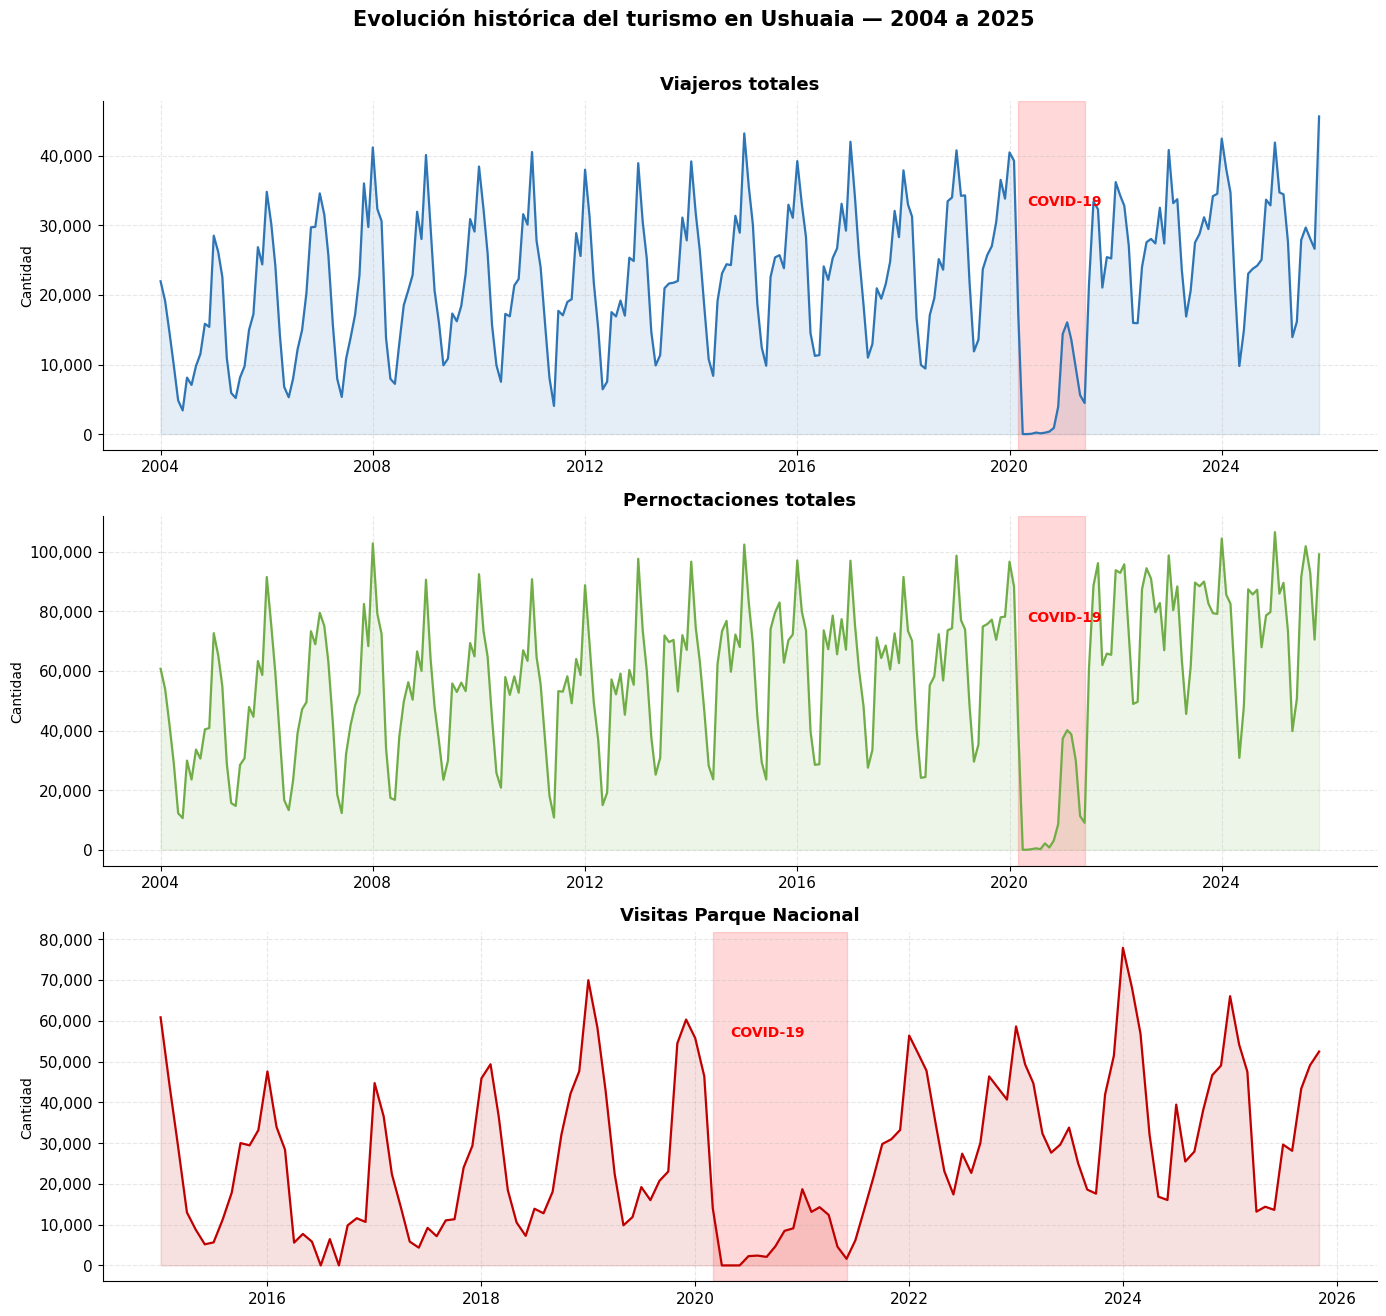

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

config = [
    ('ush_viaj_total',       'Viajeros totales',       AZUL),
    ('ush_pernoc_total',     'Pernoctaciones totales',  VERDE),
    ('parque_visitas_total', 'Visitas Parque Nacional', ROJO),
]

for ax, (col, titulo, color) in zip(axes, config):
    ax.plot(df['fecha'], df[col], color=color, linewidth=1.6)
    ax.fill_between(df['fecha'], df[col], alpha=0.12, color=color)

    # Sombrear COVID
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
               alpha=0.15, color='red')
    ax.text(pd.Timestamp('2020-05-01'),
            df[col].max() * 0.72, 'COVID-19', color='red',
            fontsize=10, fontweight='bold')

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel('Cantidad', fontsize=10)
    fmt_miles(ax)

plt.suptitle('Evolución histórica del turismo en Ushuaia — 2004 a 2025',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('docs/img/estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()


### Análisis — Evolución histórica

- **Viajeros y pernoctaciones** muestran una estacionalidad clara y repetida cada año,
  con picos en verano e invierno y valles profundos en mayo-junio.
- **El COVID (2020-2021)** provocó una caída abrupta con prácticamente nula actividad
  turística durante 16 meses. Este período fue excluido del modelo.
- **El Parque Nacional** tiene datos desde 2015 y registró su récord histórico
  en 2023-2024, superando las 75.000 visitas mensuales.
- **Las tres series se recuperaron post-COVID** y superaron los niveles previos
  a 2020, lo que indica una demanda turística creciente y robusta.

### 3.2 Estacionalidad mensual

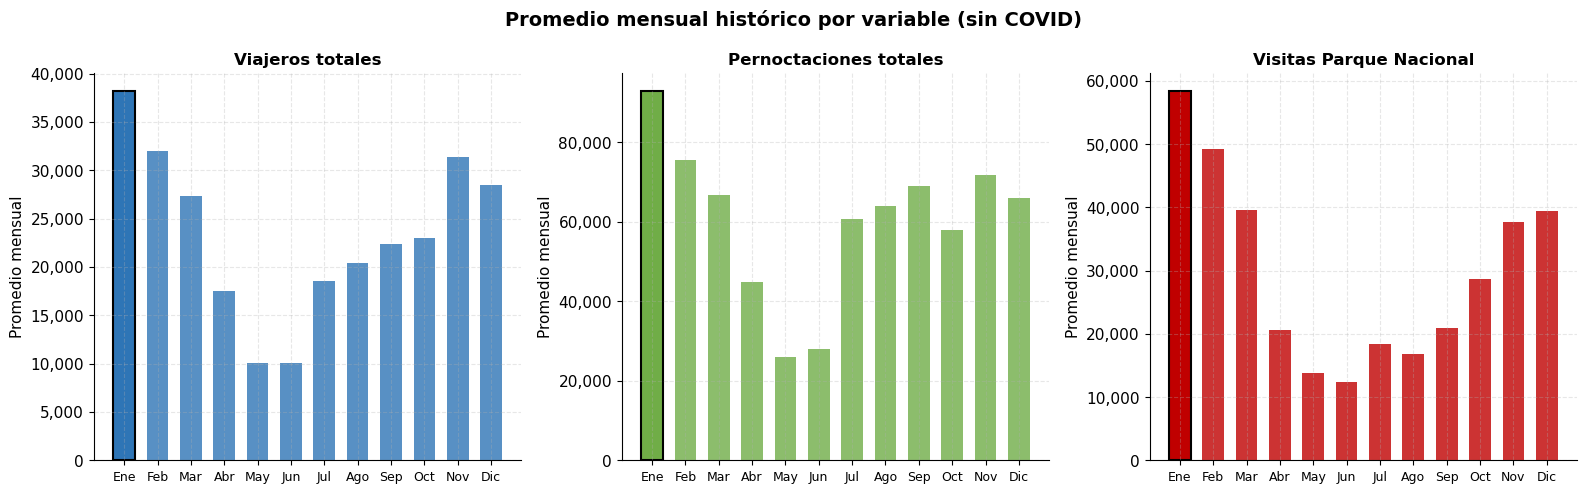

In [4]:
meses_str = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']

# Datos sin COVID para la estacionalidad
mask_covid = (df['fecha'] >= '2020-03-01') & (df['fecha'] <= '2021-06-01')
df_sin_covid = df[~mask_covid].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

config = [
    ('ush_viaj_total',       'Viajeros totales',       AZUL),
    ('ush_pernoc_total',     'Pernoctaciones totales',  VERDE),
    ('parque_visitas_total', 'Visitas Parque Nacional', ROJO),
]

for ax, (col, titulo, color) in zip(axes, config):
    por_mes = df_sin_covid.groupby('mes.1')[col].mean()
    bars = ax.bar(por_mes.index, por_mes.values,
                  color=color, alpha=0.8, width=0.65)

    # Resaltar pico máximo
    idx_max = por_mes.values.argmax()
    bars[idx_max].set_alpha(1.0)
    bars[idx_max].set_edgecolor('black')
    bars[idx_max].set_linewidth(1.5)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_str, fontsize=9)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Promedio mensual')
    fmt_miles(ax)

plt.suptitle('Promedio mensual histórico por variable (sin COVID)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Análisis — Estacionalidad mensual

Ushuaia presenta un patrón estacional muy marcado con **dos temporadas altas**:

- **Verano (enero-febrero):** pico principal impulsado por turismo internacional
  y visitas al Parque Nacional. Es la temporada de mayor volumen del año.
- **Invierno (julio-agosto):** segunda temporada alta impulsada por deportes de nieve
  en Cerro Castor. Menor volumen que el verano pero significativa.
- **Estacionamiento (mayo-junio):** meses de menor actividad turística del año.

El **Parque Nacional** muestra un comportamiento diferente al resto: su pico es
exclusivamente en verano y cae fuertemente en invierno, lo que indica que el
turista de nieve no lo visita como atractivo principal.

Este patrón justifica que el **mes** sea una de las variables más importantes
del modelo, ya que captura directamente la estacionalidad del destino.

### 3.3 Matriz de correlación

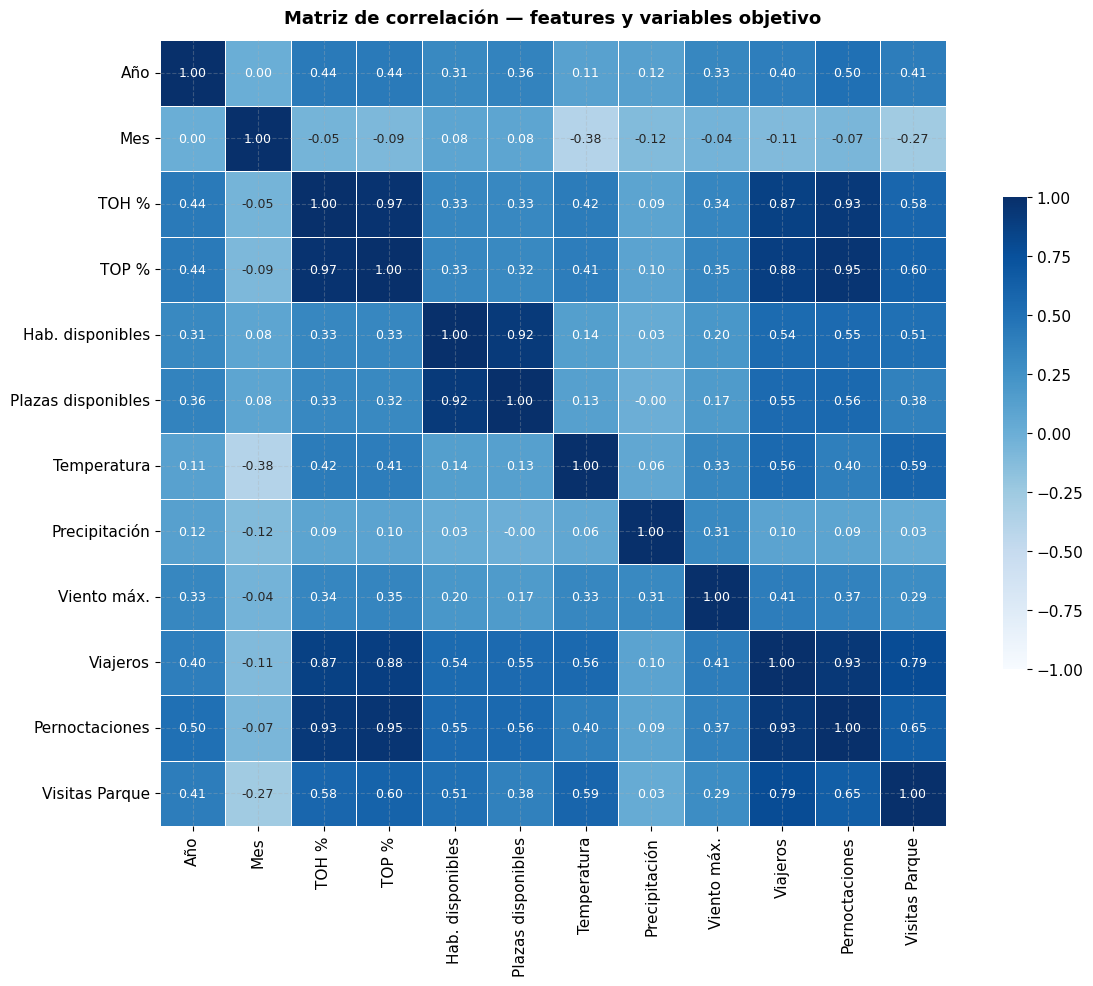

In [5]:
# Imputar nulos en variables hoteleras antes de la correlación
cols_hotel = ['ush_toh %', 'ush_top %',
              'ush_hab_disponibles', 'ush_plazas_disponibles']
for col in cols_hotel:
    df_sin_covid[col] = df_sin_covid.groupby('mes.1')[col].transform(
        lambda x: x.fillna(x.median()))

FEATURES = ['anio', 'mes.1', 'ush_toh %', 'ush_top %',
            'ush_hab_disponibles', 'ush_plazas_disponibles',
            'temperature_2m_mean', 'precipitation_sum',
            'wind_speed_10m_max']

TARGETS  = ['ush_viaj_total', 'ush_pernoc_total', 'parque_visitas_total']

cols_corr = FEATURES + TARGETS
corr = df_sin_covid[cols_corr].corr()

# Nombres más legibles para el gráfico
nombres = {
    'anio':                  'Año',
    'mes.1':                 'Mes',
    'ush_toh %':             'TOH %',
    'ush_top %':             'TOP %',
    'ush_hab_disponibles':   'Hab. disponibles',
    'ush_plazas_disponibles':'Plazas disponibles',
    'temperature_2m_mean':   'Temperatura',
    'precipitation_sum':     'Precipitación',
    'wind_speed_10m_max':    'Viento máx.',
    'ush_viaj_total':        'Viajeros',
    'ush_pernoc_total':      'Pernoctaciones',
    'parque_visitas_total':  'Visitas Parque',
}
corr.index   = [nombres.get(c, c) for c in corr.index]
corr.columns = [nombres.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.6},
            annot_kws={'size': 9})
ax.set_title('Matriz de correlación — features y variables objetivo',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### Selección de variables (features)

Las variables predictoras fueron seleccionadas con tres criterios:

**1. Pocos o cero nulos**
Variables como cruceros o desagregación por origen tienen más de 228 nulos
sobre 263 registros, lo que las hace inutilizables.

**2. Sin data leakage**
Se excluyeron variables que contienen información del target de forma indirecta.
Por ejemplo `ush_estadia_total` se calcula dividiendo pernoctaciones entre viajeros,
y `ush_hab_ocupadas` depende directamente de cuántos turistas llegaron.
Usarlas sería trampa porque el modelo aprendería con información que en la
realidad no estaría disponible al momento de predecir.

**3. Correlación confirmada por la matriz**

| Variable | Correlación con viajeros | Interpretación |
|---|---|---|
| TOH % | 0.87 | Muy fuerte — ocupación hotelera refleja la demanda |
| TOP % | 0.88 | Muy fuerte — ocupación de plazas |
| Temperatura | 0.56 | Moderada — más calor, más turistas |
| Año | 0.40 | Captura la tendencia de crecimiento histórico |
| Mes | -0.11 | Baja pero captura la estacionalidad |
| Precipitación | 0.10 | Baja, incluida por completitud |

---
## 4. Preprocesamiento

Antes de entrenar el modelo se realizaron tres pasos:

**Paso 1 — Imputación de nulos**
Los pocos valores faltantes en variables hoteleras (TOH%, TOP%, habitaciones y plazas
disponibles) se reemplazaron con la mediana histórica del mismo mes, respetando la estacionalidad.

**Paso 2 — Exclusión del período COVID**
Se eliminaron los registros de marzo 2020 a junio 2021. El COVID fue un shock externo
atípico que distorsionaría el aprendizaje del modelo ya que no representa el
comportamiento normal del turismo.

**Paso 3 — Split temporal**
Los datos se dividieron en dos grupos:
- **Train:** enero 2004 a diciembre 2022 — el modelo aprende con estos datos
- **Test:** enero 2023 a noviembre 2025 — evaluamos qué tan bien predice datos que nunca vio

Se usa split temporal (no aleatorio) porque los datos tienen orden cronológico.
Mezclar meses pasados y futuros de forma aleatoria sería trampa.

In [6]:
# 1. Imputar nulos en variables hoteleras
cols_hotel = ['ush_toh %', 'ush_top %',
              'ush_hab_disponibles', 'ush_plazas_disponibles']
for col in cols_hotel:
    df[col] = df.groupby('mes.1')[col].transform(
        lambda x: x.fillna(x.median()))

# 2. Excluir período COVID
mask_covid = (df['fecha'] >= '2020-03-01') & (df['fecha'] <= '2021-06-01')
df_modelo  = df[~mask_covid].copy()

# 3. Split temporal
df_train = df_modelo[df_modelo['anio'] <= 2022]
df_test  = df_modelo[df_modelo['anio'] >= 2023]

print(f'Registros totales (sin COVID) : {len(df_modelo)} meses')
print(f'Train — hasta dic 2022        : {len(df_train)} meses')
print(f'Test  — desde ene 2023        : {len(df_test)} meses')


Registros totales (sin COVID) : 247 meses
Train — hasta dic 2022        : 212 meses
Test  — desde ene 2023        : 35 meses


In [10]:
# ── Selección de features con Sequential Feature Selector ───────────

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Preparar datos solo para viajeros totales
df_viaj = df_modelo.dropna(subset=['ush_viaj_total'] + FEATURES)

X = df_viaj[FEATURES].values
y = df_viaj['ush_viaj_total'].values

# Aplicar stepwise (both = forward + backward)
sfs = SFS(
    LinearRegression(),
    k_features   = 'best',    # elige automáticamente cuántas features
    forward      = True,
    floating     = True,       # permite quitar features ya elegidas (stepwise real)
    scoring      = 'r2',
    cv           = 5
)

sfs.fit(X, y)

# Resultados
features_elegidas = [FEATURES[i] for i in sfs.k_feature_idx_]
print(f'Features seleccionadas ({len(features_elegidas)}):')
for f in features_elegidas:
    print(f'  {f}')
print(f'\nR² con features seleccionadas: {sfs.k_score_:.3f}')

Features seleccionadas (5):
  mes.1
  ush_top %
  ush_plazas_disponibles
  temperature_2m_mean
  wind_speed_10m_max

R² con features seleccionadas: 0.878
